In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
#Renaming df columns 
df.rename(columns={'PE':'EP'},inplace=True)
print(list(df.columns))

['AT', 'V', 'AP', 'RH', 'EP']


In [4]:
def check_missing_values(dataframe):
    missing_values = dataframe.isnull().sum()
    print("Missing values in each column:")
    print(missing_values)

check_missing_values(df)

Missing values in each column:
AT    0
V     0
AP    0
RH    0
EP    0
dtype: int64


In [5]:
df.shape

(9568, 5)

In [6]:
df.dtypes

AT    float64
V     float64
AP    float64
RH    float64
EP    float64
dtype: object

In [7]:
#Statistics of each feature and PE
df.describe()

,AT,V,AP,RH,EP
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [8]:
for column in df.columns:
    print(f"The min value of {column} is {min(df[column])}")
    print(f"The max value of {column} is {max(df[column])}")
    print(f"Range of {column} is {max(df[column]) - min(df[column])}")
    print("\n")
    

The min value of AT is 1.81
The max value of AT is 37.11
Range of AT is 35.3


The min value of V is 25.36
The max value of V is 81.56
Range of V is 56.2


The min value of AP is 992.89
The max value of AP is 1033.3
Range of AP is 40.40999999999997


The min value of RH is 25.56
The max value of RH is 100.16
Range of RH is 74.6


The min value of EP is 420.26
The max value of EP is 495.76
Range of EP is 75.5




AT - Average Temperature /C
V - Exhaust Vaccum 
AP - Ambient Pressure
RH - Relative Humidity
EP - Energy Output

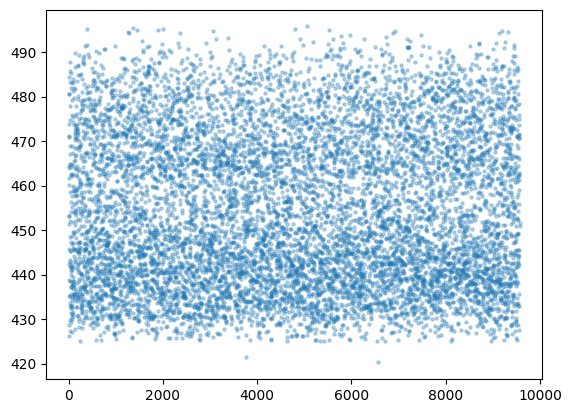

In [9]:
#Exploratory data analysis
plt.scatter(df.index,df['EP'],alpha=0.3,s=5)
plt.show()

In [10]:
#Checking for missing values in the dataset
# def check_missing_values(dataframe):
#     missing_values = dataframe.isnull().sum()
#     print("Missing values in each column:")
#     print(missing_values)

# check_missing_values(df)

In [11]:
#Splitting dataset into train and test sets
X = df.drop('EP', axis = 1)
y = df['EP']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (7654, 4), Test set: (1914, 4)


In [12]:
#Linear Regression
lr = LinearRegression()
lr_model = lr.fit(X_train,y_train)

#Linear Regression Evaluation
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
sse_lr = np.sum((y_test - y_pred_lr)**2)
n = len(y_test)
p = X_test.shape[1]
adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)

print(f"Linear Regression MSE: {mse_lr:.4f}")
print(f"Linear Regression SSE: {sse_lr:.4f}")
print(f"Linear Regression R²: {r2_lr:.4f}")
print(f"Linear Regression Adjusted R²: {adj_r2_lr:.4f}")


Linear Regression MSE: 19.6081
Linear Regression SSE: 37529.8753
Linear Regression R²: 0.9315
Linear Regression Adjusted R²: 0.9313


In [19]:
coefficients = lr_model.coef_
intercept = lr_model.intercept_

coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})
coeff_df

,Feature,Coefficient
0,AT,-1.976966
1,V,-0.234769
2,AP,0.058253
3,RH,-0.158146


In [13]:
#Random Forest Regressor
rfr = RandomForestRegressor()
rfr_model = rfr.fit(X_train, y_train)

#Random Forest Evaluation
y_pred_rfr = rfr_model.predict(X_test)
mse_rfr = mean_squared_error(y_test, y_pred_rfr)
r2_rfr = r2_score(y_test, y_pred_rfr)
sse_rfr = np.sum((y_test - y_pred_rfr)**2)
adj_r2_rfr = 1 - (1 - r2_rfr) * (n - 1) / (n - p - 1)
print(f"Random Forest Regression MSE: {mse_rfr:.4f}")
print(f"Random Forest Regression SSE: {sse_rfr:.4f}")
print(f"Random Forest Regression R²: {r2_rfr:.4f}")
print(f"Random Forest Regression Adjusted R²: {adj_r2_rfr:.4f}")

Random Forest Regression MSE: 10.1630
Random Forest Regression SSE: 19451.9983
Random Forest Regression R²: 0.9645
Random Forest Regression Adjusted R²: 0.9644
